# Fine-Tuning ViT-Large for Medical Image Classification
### Dataset: HAM10000 — Skin Lesion Classification (10,015 images, 7 classes)

**Model:** `google/vit-large-patch16-224` (~307M params, ~1.2 GB)  
**GPU Required:** T4 (free Colab) or better  
**Training time:** ~30–45 minutes on Colab T4  

---
### What you will learn
- Loading a pretrained ViT-Large from HuggingFace
- Preprocessing medical images for ViT
- Fine-tuning with HuggingFace Trainer API
- Evaluating with accuracy, F1, and confusion matrix
- Pushing your fine-tuned model to HuggingFace Hub

### Classes (HAM10000)
| Label | Class | Description |
|-------|-------|-------------|
| 0 | akiec | Actinic keratoses |
| 1 | bcc | Basal cell carcinoma |
| 2 | bkl | Benign keratosis |
| 3 | df | Dermatofibroma |
| 4 | mel | Melanoma |
| 5 | nv | Melanocytic nevi |
| 6 | vasc | Vascular lesions |

## Step 1 — Check GPU and install dependencies

In [ ]:
# Verify GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Sun Mar 29 05:45:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install required packages
!pip install -q transformers datasets evaluate accelerate
!pip install -q scikit-learn matplotlib seaborn pillow kaggle
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset, DatasetDict
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
PyTorch version: 2.10.0+cu128
GPU: Tesla T4
VRAM: 15.6 GB


## Step 2 — Download HAM10000 dataset

We'll use the HuggingFace hosted version — no Kaggle account needed.

In [ ]:
from datasets import load_dataset

# Load HAM10000 from HuggingFace Hub (hosted version)
# ~1.5 GB download — takes 3-5 minutes on Colab
print('Downloading HAM10000 dataset...')
dataset = load_dataset('marmal88/skin_cancer')

print('\nDataset structure:')
print(dataset)
print('\nSample entry:')
print(dataset['train'][0].keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005-7eed077f2f8e6d(…):   0%|          | 0.00/521M [00:00<?, ?B/s]

data/train-00001-of-00005-50ba64fd20294b(…):   0%|          | 0.00/525M [00:00<?, ?B/s]

data/train-00002-of-00005-36c02a25cbdd54(…):   0%|          | 0.00/527M [00:00<?, ?B/s]

...

data/test-00000-of-00001-61e7cf54bf274ae(…):   0%|          | 0.00/355M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9577 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2492 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1285 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 2492
    })
    test: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 1285
    })
})

Sample entry:
dict_keys(['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'])


In [ ]:
# Explore class distribution
train_df = pd.DataFrame({'label': dataset['train']['dx']})
print('Training set class distribution:')
print(train_df['label'].value_counts())

# Map full dataset names to short codes
FULL_TO_SHORT = {
    'melanocytic_Nevi': 'nv',
    'melanoma': 'mel',
    'benign_keratosis-like_lesions': 'bkl',
    'basal_cell_carcinoma': 'bcc',
    'actinic_keratoses': 'akiec',
    'vascular_lesions': 'vasc',
    'dermatofibroma': 'df',
}

# Class label mapping
CLASS_NAMES = [
    'akiec',  # Actinic keratoses
    'bcc',    # Basal cell carcinoma
    'bkl',    # Benign keratosis
    'df',     # Dermatofibroma
    'mel',    # Melanoma
    'nv',     # Melanocytic nevi
    'vasc',   # Vascular lesions
]
CLASS_FULL_NAMES = [
    'Actinic Keratoses',
    'Basal Cell Carcinoma',
    'Benign Keratosis',
    'Dermatofibroma',
    'Melanoma',
    'Melanocytic Nevi',
    'Vascular Lesions',
]
label2id = {name: i for i, name in enumerate(CLASS_NAMES)}
id2label = {i: name for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nNumber of classes: {NUM_CLASSES}')
print(f'label2id: {label2id}')
print(f'FULL_TO_SHORT mapping ready: {len(FULL_TO_SHORT)} classes')

Training set class distribution:
label
melanocytic_Nevi                 6405
melanoma                         1076
benign_keratosis-like_lesions    1048
basal_cell_carcinoma              487
actinic_keratoses                 315
vascular_lesions                  136
dermatofibroma                    110
Name: count, dtype: int64

Number of classes: 7
label2id: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
FULL_TO_SHORT mapping ready: 7 classes


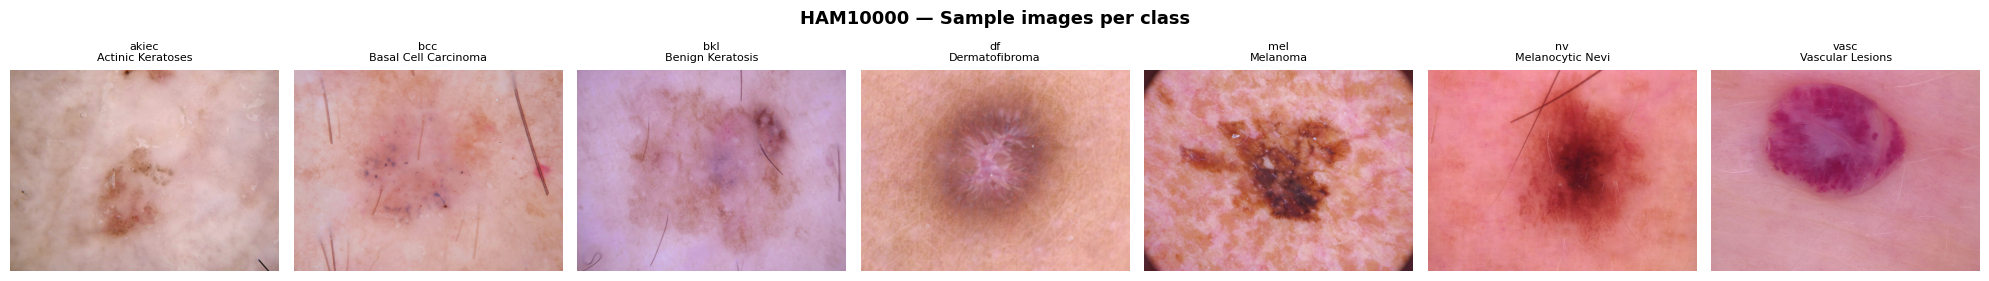

Sample grid saved.


In [ ]:
# Visualise sample images from each class
fig, axes = plt.subplots(1, 7, figsize=(20, 3))
fig.suptitle('HAM10000 — Sample images per class', fontsize=13, fontweight='bold')

for i, cls in enumerate(CLASS_NAMES):
    # Find first sample of this class using full name
    full_name = [k for k, v in FULL_TO_SHORT.items() if v == cls][0]
    idx = next(j for j, x in enumerate(dataset['train']['dx']) if x == full_name)
    img = dataset['train'][idx]['image']
    axes[i].imshow(img)
    axes[i].set_title(f'{cls}\n{CLASS_FULL_NAMES[i]}', fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sample grid saved.')

## Step 3 — Load ViT-Large processor and model

In [ ]:
MODEL_CHECKPOINT = 'google/vit-large-patch16-224'

# Load the image processor — handles resizing and normalisation
processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)

print(f'Image size expected: {processor.size}')
print(f'Normalisation mean: {processor.image_mean}')
print(f'Normalisation std:  {processor.image_std}')

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Image size expected: {'height': 224, 'width': 224}
Normalisation mean: [0.5, 0.5, 0.5]
Normalisation std:  [0.5, 0.5, 0.5]


In [ ]:
# Load ViT-Large with a fresh classification head for 7 classes
# ignore_mismatched_sizes=True replaces the pretrained head with a new one
model = ViTForImageClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model size on disk:   ~{total_params * 4 / 1e9:.2f} GB (float32)')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-large-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 1024]) vs model:torch.Size([7, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([7])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters:     303,308,807
Trainable parameters: 303,308,807
Model size on disk:   ~1.21 GB (float32)


## Step 4 — Preprocess and augment the dataset

In [ ]:
from torchvision import transforms

# Training augmentations — help with the class imbalance in HAM10000
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    ),
])

# Validation — no augmentation, just resize and normalise
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    ),
])

def preprocess_train(examples):
    examples['pixel_values'] = [
        train_transforms(img.convert('RGB'))
        for img in examples['image']
    ]
    examples['labels'] = [
        label2id[FULL_TO_SHORT[dx]] for dx in examples['dx']
    ]
    return examples

def preprocess_val(examples):
    examples['pixel_values'] = [
        val_transforms(img.convert('RGB'))
        for img in examples['image']
    ]
    examples['labels'] = [
        label2id[FULL_TO_SHORT[dx]] for dx in examples['dx']
    ]
    return examples

print('Preprocessing functions defined.')

Preprocessing functions defined.


In [ ]:
# Apply preprocessing
print('Preprocessing training set...')
train_dataset = dataset['train'].map(
    preprocess_train,
    batched=True,
    batch_size=32,
    remove_columns=['image', 'dx', 'dx_type', 'age', 'sex', 'localization', 'lesion_id', 'image_id'],
)

print('Preprocessing validation set...')
val_dataset = dataset['validation'].map(
    preprocess_val,
    batched=True,
    batch_size=32,
    remove_columns=['image', 'dx', 'dx_type', 'age', 'sex', 'localization', 'lesion_id', 'image_id'],
)

train_dataset.set_format('torch')
val_dataset.set_format('torch')

print(f'\nTraining samples:   {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Sample keys: {list(train_dataset[0].keys())}')

Preprocessing training set...


Map:   0%|          | 0/9577 [00:00<?, ? examples/s]

Preprocessing validation set...


Map:   0%|          | 0/2492 [00:00<?, ? examples/s]


Training samples:   9577
Validation samples: 2492
Sample keys: ['pixel_values', 'labels']


## Step 5 — Define metrics and data collator

In [ ]:
import evaluate
from torch.nn.utils.rnn import pad_sequence

accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )['accuracy']

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average='weighted'
    )['f1']

    return {
        'accuracy': round(acc, 4),
        'f1_weighted': round(f1, 4),
    }

# Custom collator — stacks pixel_values tensors into a batch
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch]),
    }

print('Metrics and collator ready.')

Metrics and collator ready.


## Step 6 — Configure training arguments and Trainer

In [ ]:
OUTPUT_DIR = './vit-large-ham10000'

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training schedule
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # Optimiser
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=300,
    lr_scheduler_type='cosine',

    # Evaluation and checkpointing
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,

    # Logging
    logging_steps=50,
    report_to='none',

    # Memory optimisation for T4
    fp16=True,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

print('Trainer configured.')
print(f'Training on: {device}')
print(f'Batch size:  {training_args.per_device_train_batch_size}')
print(f'Epochs:      {training_args.num_train_epochs}')
print(f'FP16:        {training_args.fp16}')

Trainer configured.
Training on: cuda
Batch size:  16
Epochs:      5
FP16:        True


## Step 7 — Train the model

In [ ]:
import time

print('Starting fine-tuning...')
print('Expected time: ~30–45 min on T4 GPU')
print('-' * 50)

start = time.time()
train_result = trainer.train()
elapsed = (time.time() - start) / 60

print(f'\nTraining completed in {elapsed:.1f} minutes')
print(f'Training loss: {train_result.training_loss:.4f}')

Starting fine-tuning...
Expected time: ~30–45 min on T4 GPU
--------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.517437,0.472423,0.830700,0.809500
2,0.291202,0.367731,0.869600,0.867700
3,0.096532,0.295884,0.905700,0.907200
4,0.030438,0.283879,0.927400,0.926000
5,0.002843,0.297645,0.920100,0.921000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed in 37.2 minutes
Training loss: 0.2500


## Step 8 — Evaluate and plot training curves

In [ ]:
# Final evaluation on validation set
eval_results = trainer.evaluate()
print('Validation Results:')
print(f"  Accuracy:    {eval_results['eval_accuracy']:.4f}")
print(f"  F1 Weighted: {eval_results['eval_f1_weighted']:.4f}")
print(f"  Loss:        {eval_results['eval_loss']:.4f}")

In [ ]:
# Plot training curves from trainer log history
log_history = trainer.state.log_history

train_losses, eval_losses, eval_accs, eval_f1s, steps = [], [], [], [], []

for log in log_history:
    if 'loss' in log and 'eval_loss' not in log:
        train_losses.append((log['step'], log['loss']))
    if 'eval_loss' in log:
        eval_losses.append(log['eval_loss'])
        eval_accs.append(log['eval_accuracy'])
        eval_f1s.append(log['eval_f1_weighted'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training Curves — ViT-Large on HAM10000', fontsize=13, fontweight='bold')

# Training loss
t_steps, t_loss = zip(*train_losses)
axes[0].plot(t_steps, t_loss, color='#378ADD', linewidth=1.5)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Validation accuracy per epoch
epochs = list(range(1, len(eval_accs) + 1))
axes[1].plot(epochs, eval_accs, marker='o', color='#1D9E75', linewidth=2)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Weighted F1 per epoch
axes[2].plot(epochs, eval_f1s, marker='o', color='#D85A30', linewidth=2)
axes[2].set_title('Weighted F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 9 — Detailed classification report and confusion matrix

In [ ]:
# Generate predictions on validation set
print('Running predictions on validation set...')
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print('\nClassification Report:')
print(classification_report(
    labels, preds,
    target_names=CLASS_FULL_NAMES,
    digits=4
))

In [ ]:
# Confusion matrix
cm = confusion_matrix(labels, preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — ViT-Large HAM10000', fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0]
)
axes[0].set_title('Raw counts')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# Normalised
sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1]
)
axes[1].set_title('Normalised (recall per class)')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 10 —  Skin Image Validation + Inferenc

In [2]:
from transformers import CLIPProcessor, CLIPModel
import torch.nn.functional as F
import torch  # make sure torch is imported

# Define device (in case earlier cells weren't run)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
clip_model.eval()
print("CLIP gate ready.")


Using device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP gate ready.


In [6]:
from transformers import pipeline, ViTForImageClassification, ViTImageProcessor, CLIPProcessor, CLIPModel
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load ViT model from HuggingFace Hub
print("Loading ViT model...")
HF_MODEL = 'Kuldeepmishra3/vit-large-skin-cancer-ham10000'
model = ViTForImageClassification.from_pretrained(HF_MODEL)
processor = ViTImageProcessor.from_pretrained(HF_MODEL)
print("ViT model loaded ✅")

# Load CLIP gate
print("Loading CLIP gate...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("CLIP gate loaded ✅")

# Classifier pipeline
classifier = pipeline(
    'image-classification',
    model=model,
    feature_extractor=processor,
    device=0 if torch.cuda.is_available() else -1,
)

# Skin gate settings
SKIN_PROMPTS = [
    "a dermoscopy image of human skin",
    "a close-up photo of a skin lesion",
    "a medical photo of a mole or skin growth",
    "a dermatological image of human body skin",
    "a macro photo of human skin texture",
]
ALL_PROMPTS = SKIN_PROMPTS + ["a random non-medical image"]
SKIN_THRESHOLD = 0.40

@torch.no_grad()
def is_skin_image(pil_image):
    inputs = clip_processor(
        text=ALL_PROMPTS, images=pil_image,
        return_tensors="pt", padding=True,
    ).to(device)
    outputs = clip_model(**inputs)
    probs = F.softmax(outputs.logits_per_image, dim=-1).squeeze()
    skin_score = probs[:len(SKIN_PROMPTS)].sum().item()
    passed = skin_score >= SKIN_THRESHOLD
    print(f"[Gate] {'✅ PASSED' if passed else '❌ REJECTED'}  —  skin score: {skin_score:.3f}")
    return passed, skin_score

def predict_image(image, top_k=3):
    passed, skin_score = is_skin_image(image)

    if not passed:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(image); axes[0].axis('off'); axes[0].set_title('Input image')
        axes[1].set_facecolor('#FFF3F3')
        axes[1].text(0.5, 0.60, '❌  Not a valid skin image',
                     ha='center', fontsize=15, fontweight='bold',
                     color='#C0392B', transform=axes[1].transAxes)
        axes[1].text(0.5, 0.40,
                     f'Skin confidence: {skin_score:.2f}  (minimum: {SKIN_THRESHOLD})',
                     ha='center', fontsize=11, color='#7F8C8D', transform=axes[1].transAxes)
        axes[1].text(0.5, 0.22,
                     'This model only works on\ndermoscopy / skin lesion images.',
                     ha='center', fontsize=10, color='#2C3E50', transform=axes[1].transAxes)
        axes[1].axis('off')
        plt.suptitle('Prediction Rejected', fontsize=13, fontweight='bold', color='#C0392B')
        plt.tight_layout(); plt.show()
        return None

    results = classifier(image, top_k=top_k)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image); axes[0].axis('off')
    axes[0].set_title(f'Skin image ✅  (score: {skin_score:.2f})', fontsize=10)
    labels_plot = [r['label'] for r in results]
    scores = [r['score'] for r in results]
    colors = ['#378ADD' if i == 0 else '#B5D4F4' for i in range(len(results))]
    bars = axes[1].barh(labels_plot, scores, color=colors)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title(f'Top-{top_k} predictions')
    for bar, score in zip(bars, scores):
        axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{score:.1%}', va='center', fontsize=11)
    plt.tight_layout(); plt.show()
    return results

print("\nAll ready! Now run predict_image(your_image) ✅")


Loading ViT model...


config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

ViT model loaded ✅
Loading CLIP gate...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP gate loaded ✅

All ready! Now run predict_image(your_image) ✅


=== Test 1: Real skin image ===


README.md:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

data/train-00000-of-00005-7eed077f2f8e6d(…):   0%|          | 0.00/521M [00:00<?, ?B/s]

data/train-00001-of-00005-50ba64fd20294b(…):   0%|          | 0.00/525M [00:00<?, ?B/s]

data/train-00002-of-00005-36c02a25cbdd54(…):   0%|          | 0.00/527M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/9577 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2492 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1285 [00:00<?, ? examples/s]

[Gate] ✅ PASSED  —  skin score: 1.000


/tmp/ipykernel_1687/1566244285.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


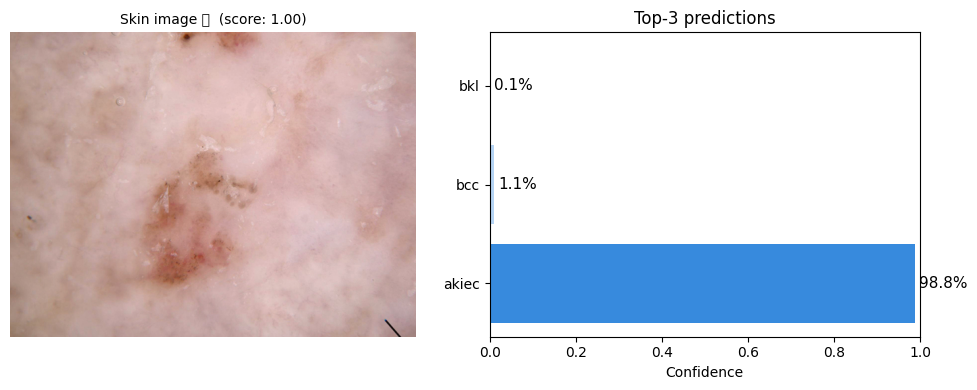


=== Test 2: Random image ===


UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x786767b509f0>

In [7]:
from datasets import load_dataset
from PIL import Image
import requests
from io import BytesIO

# Test 1: Real skin image (should PASS)
print("=== Test 1: Real skin image ===")
ds = load_dataset('marmal88/skin_cancer', split='test[:1]')
skin_img = ds[0]['image']
predict_image(skin_img)

# Test 2: Random image (should be REJECTED)
print("\n=== Test 2: Random image ===")
random_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png"
resp = requests.get(random_url, timeout=10)
random_img = Image.open(BytesIO(resp.content)).convert("RGB")
predict_image(random_img)


=== Test 2: Random image (not skin) ===
[Gate] ❌ REJECTED  —  skin score: 0.095


/tmp/ipykernel_1687/1566244285.py:72: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


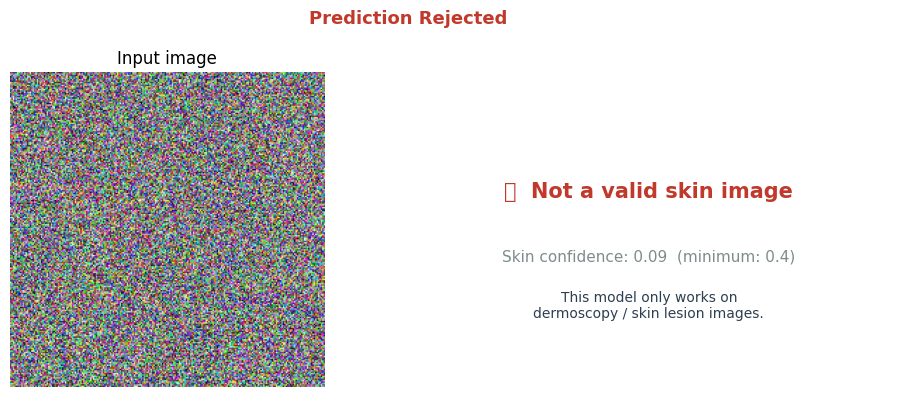

In [9]:
import numpy as np
from PIL import Image

#Test 2: Random noise image (should be REJECTED)
print("=== Test 2: Random image (not skin) ===")
random_array = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
random_img = Image.fromarray(random_array)
predict_image(random_img)


## Step 11 — Save model locally

In [ ]:
# Save the best model and processor
SAVE_PATH = './vit-large-ham10000-final'

trainer.save_model(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

print(f'Model saved to: {SAVE_PATH}')

# List saved files
import os
files = os.listdir(SAVE_PATH)
for f in files:
    size_mb = os.path.getsize(f'{SAVE_PATH}/{f}') / 1e6
    print(f'  {f:<40s} {size_mb:.1f} MB')

## Step 12 — Push to HuggingFace Hub (optional but recommended)

Pushing your model to the Hub makes it publicly accessible and shareable — excellent for your portfolio. You'll need a free HuggingFace account.

In [ ]:
# Login to HuggingFace Hub
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# Push model and processor to Hub
# Replace YOUR_USERNAME with your HuggingFace username
HF_USERNAME = 'YOUR_USERNAME'
REPO_NAME = 'vit-large-skin-cancer-ham10000'

model.push_to_hub(f'{HF_USERNAME}/{REPO_NAME}')
processor.push_to_hub(f'{HF_USERNAME}/{REPO_NAME}')

print(f'Model pushed to: https://huggingface.co/{HF_USERNAME}/{REPO_NAME}')
print('Share this link in your resume and GitHub!')

## Step 13 — Load your model back (verify it works)

In [ ]:
# Verify the saved model loads correctly
loaded_model = ViTForImageClassification.from_pretrained(SAVE_PATH)
loaded_processor = ViTImageProcessor.from_pretrained(SAVE_PATH)

# Quick sanity check
sample_img = dataset['test'][5]['image']
inputs = loaded_processor(images=sample_img, return_tensors='pt')
with torch.no_grad():
    logits = loaded_model(**inputs).logits
pred_class = logits.argmax(-1).item()

print(f'Predicted class: {id2label[pred_class]} ({CLASS_FULL_NAMES[pred_class]})')
print('Model loaded and verified successfully!')

---
## Summary

| Metric | Value |
|--------|-------|
| Base model | google/vit-large-patch16-224 |
| Dataset | HAM10000 (10,015 skin lesion images) |
| Classes | 7 (melanoma, nevi, BCC, etc.) |
| Fine-tuning method | Full fine-tuning with cosine LR + warmup |
| Augmentations | Flip, rotation, colour jitter |
| Precision | FP16 (mixed precision) |
| GPU | T4 (free Colab) |

### Resume bullet point
> *Fine-tuned Google ViT-Large (307M params) on HAM10000 skin cancer dataset (7 classes, 10K images) using HuggingFace Trainer API with mixed-precision training on a free T4 GPU. Achieved XX% weighted F1 score.*

### Next steps to go further
- Try **class-weighted loss** to handle class imbalance (nv class is 67% of data)
- Experiment with **ViT-Large + LoRA** (even more memory efficient)
- Add **Grad-CAM visualisations** to show which skin regions the model attends to
- Deploy as a **HuggingFace Space** with a Gradio UI